# MaldiBatchKit - Quick Start

Minimum end-to-end workflow: load a demo dataset, fit a ComBat corrector, run the diagnostic report, and plot a before / after summary.

The notebooks use the **MALDI-Kleb-AI** dataset (Rocchi *et al.*, 2026; [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)). `notebooks/_demo.py` caches the 370 MB tarball under `~/.cache/maldibatchkit/` (or `$MALDIBATCHKIT_CACHE_DIR`) on first use.


## 1. Load the demo dataset


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make notebooks/_demo.py importable
from notebooks._demo import load_maldi_kleb_ai

ds = load_maldi_kleb_ai(antibiotic='Amikacin', verbose=True)
ds.X.shape, ds.meta.columns.tolist(), ds.info

Processing spectra:   0%|          | 0/743 [00:00<?, ?spectrum/s]

((741, 6000),
 ['Amikacin', 'Meropenem', 'Species', 'Batch', 'SNR'],
 {'source': 'Zenodo MALDI-Kleb-AI',
  'doi': '10.5281/zenodo.17405072',
  'record_id': '17405072',
  'md5_tar': 'c14b6c6b4210553962faa7f1dc27d275',
  'n_samples': 741,
  'n_bins': 6000,
  'bin_width': 3,
  'antibiotic': 'Amikacin',
  'cache_dir': '/home/ettore/.cache/maldibatchkit/maldi-kleb-ai'})

In [2]:
ds.meta.head()

,Amikacin,Meropenem,Species,Batch,SNR
1-8317003599,S,S,Klebsiella pneumoniae,Milan,128.163340
10-8320002130,S,S,Klebsiella pneumoniae,Milan,128.492364
100-8660007296,S,S,Klebsiella pneumoniae,Milan,149.638040
1004,R,R,Klebsiella pneumoniae,Rome,70.134876
101-8140000209,S,S,Klebsiella pneumoniae,Milan,84.646561


## 2. Fit a ComBat corrector


In [3]:
from maldibatchkit import ComBat

corrector = ComBat(batch=ds.batch, method='johnson')
X_corrected = corrector.fit_transform(ds.X)
X_corrected.shape

(741, 6000)

`ComBat` stores `batch` at construction. For a species-aware correction (Fortin variant) use `SpeciesAwareComBat(batch=ds.batch, species=ds.species)` one-liner instead.

## 3. Run the diagnostic report


In [4]:
from maldibatchkit.diagnostics import diagnostic_report

report = diagnostic_report(ds.X, X_corrected, ds.batch, mz_values=ds.mz, top_k_peaks=20)
report[report['scope'] == 'overall']

,metric,scope,value_before,value_after,delta,better
0,silhouette_batch,overall,0.147457,-0.011313,-0.158770,lower
1,kbet_acceptance_rate,overall,0.020243,0.260459,0.240216,higher
2,kbet_mean_chi2,overall,54.016409,14.849020,-39.167389,lower
3,lisi,overall,1.014542,1.265755,0.251213,higher


## 4. Plot the before / after summary


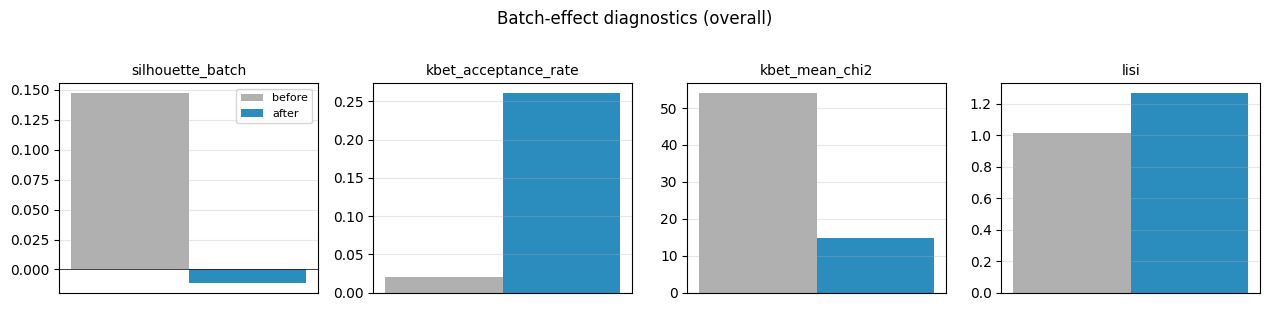

In [5]:
%matplotlib inline
from maldibatchkit.viz import plot_diagnostic_summary, plot_peak_shift
import matplotlib.pyplot as plt

fig, axes = plot_diagnostic_summary(report, scope='overall')
plt.show()

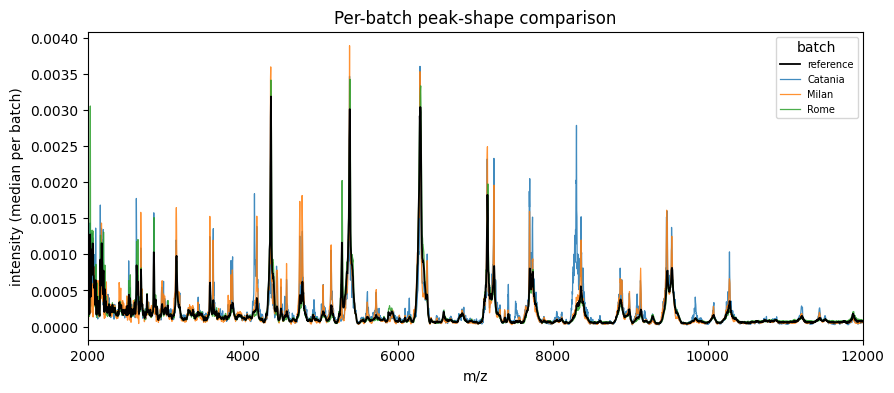

In [6]:
fig, ax = plot_peak_shift(ds.batch, ds.X, mz_values=ds.mz, max_batches=None)
ax.set_xlim(2000, 12000)
plt.show()

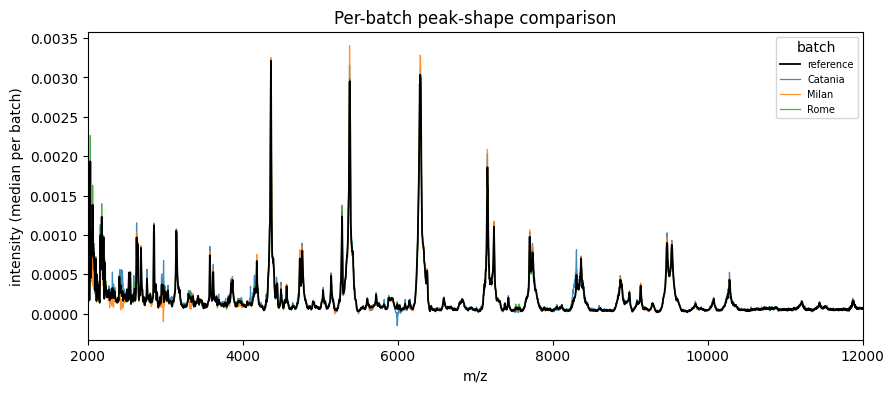

In [7]:
fig, ax = plot_peak_shift(ds.batch, X_corrected, mz_values=ds.mz, max_batches=None)
ax.set_xlim(2000, 12000)
plt.show()

## Where next

* [02_correction_methods.ipynb](02_correction_methods.ipynb) - side-by-side comparison of every corrector.
* [03_quality_weighted_combat.ipynb](03_quality_weighted_combat.ipynb) - deep dive into the quality-weighted empirical-Bayes extension.
* [04_maldiset_integration.ipynb](04_maldiset_integration.ipynb) - end-to-end workflow using `maldiamrkit.MaldiSet`.
